# One-Armed Bandit / Multi-Armed Bandit Case Study

![Picking one armed bandit](https://github.com/ValRCS/RBS_PBM773_Introduction_to_AI/blob/main/img/ch22_reinforcement_learning/Choosing_one_armed_bandit.png?raw=true)

This notebook is a compact classroom case study on the **multi-armed bandit** problem: the simplest reinforcement learning setting in which an agent must choose between **exploration** and **exploitation**.

A bandit problem removes almost everything except the core decision difficulty:

- there is **no state transition structure** to reason about,
- each action has an **unknown reward distribution**,
- the learner must decide whether to:
  - **exploit** the arm that currently looks best, or
  - **explore** other arms that might turn out to be better.

This makes the bandit setting an excellent first example before full Markov decision processes and temporal-difference methods.

The broader reinforcement learning framing used here follows the standard chapter structure in *Artificial Intelligence: A Modern Approach*, where RL is introduced as learning from reward signals rather than labeled action examples.

## Learning goals

By the end of this notebook, students should be able to explain:

1. what a multi-armed bandit problem is,
2. why **greedy** behavior can fail,
3. how **$\varepsilon$-greedy** introduces exploration,
4. how **optimistic initialization** can force early exploration,
5. what **regret** means,
6. why this example gives intuition for **GLIE** (*greedy in the limit with infinite exploration*).

In the language of reinforcement learning, this notebook focuses on the **exploration vs exploitation tradeoff**, a central issue in active reinforcement learning.

## Problem setup

Imagine a row of slot machines in a casino.

- Each machine is an **arm**.
- Pulling arm $a$ yields a reward sampled from an **unknown distribution**.
- The agent does **not** know in advance which arm is best.
- The objective is to maximize **cumulative reward** over repeated pulls.

For a simple classroom version, we will use **Bernoulli bandits**:

Based on Bernoulli distribution

![Jacob](https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/Jakob_Bernoulli.jpg/500px-Jakob_Bernoulli.jpg)

- each arm has a fixed but unknown probability of reward 1,
- otherwise the reward is 0.

Example:

- Arm A pays out with probability 0.20
- Arm B pays out with probability 0.35
- Arm C pays out with probability 0.70
- Arm D pays out with probability 0.50
- Arm E pays out with probability 0.40

The learner sees only the rewards it actually receives from the arms it has chosen.

## Why this works pedagogically

This example is strong for teaching because it isolates the key difficulty:

- **uncertainty** is present,
- **learning** is necessary,
- but there is **no state space** to distract from the main idea.

That makes it ideal for introducing:

- action-value estimates,
- greedy behavior,
- random exploration,
- optimistic exploration,
- cumulative reward,
- regret.

It also prepares students for later reinforcement learning ideas where the agent must learn not only which immediate action is promising, but also how actions affect future states.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots larger and cleaner for classroom use
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

# Reproducibility
GLOBAL_SEED = 2026
rng = np.random.default_rng(GLOBAL_SEED)

## Environment: a Bernoulli bandit

The environment is intentionally minimal.

- `probs[a]` is the true success probability of arm `a`
- `pull(a)` returns either 1 or 0

In [3]:
class BernoulliBandit:
    def __init__(self, probs, seed=None):
        self.probs = np.array(probs, dtype=float)
        self.k = len(probs)
        self.rng = np.random.default_rng(seed)

    def pull(self, arm):
        return 1 if self.rng.random() < self.probs[arm] else 0

    @property
    def best_arm(self):
        return int(np.argmax(self.probs))

    @property
    def best_mean(self):
        return float(np.max(self.probs))

## The agent

We will implement a simple sample-average action-value learner.

For each arm $a$, the agent stores:

- $N(a)$ = how many times the arm has been selected
- $Q(a)$ = current estimate of the arm's expected reward

After receiving reward $R$ from arm $a$, the sample-average update is:

\[
Q(a) \leftarrow Q(a) + \frac{1}{N(a)} \bigl(R - Q(a)\bigr)
\]

This is just the incremental form of the average of observed rewards.

In [4]:
class EpsilonGreedyAgent:
    def __init__(self, k, epsilon=0.1, initial_value=0.0, seed=None):
        self.k = k
        self.epsilon = float(epsilon)
        self.initial_value = float(initial_value)
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.q = np.full(self.k, self.initial_value, dtype=float)
        self.counts = np.zeros(self.k, dtype=int)

    def select_action(self):
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.k))
        return int(np.argmax(self.q))

    def update(self, action, reward):
        self.counts[action] += 1
        n = self.counts[action]
        self.q[action] += (reward - self.q[action]) / n

## Running one experiment

We will compare three strategies:

### 1. Pure greedy
- $\varepsilon = 0$
- initial values $Q(a)=0$
- no random exploration at all

### 2. $\varepsilon$-greedy
- with probability $\varepsilon$, pick a random arm
- otherwise exploit the current best estimate

### 3. Optimistic initialization
- still greedy after starting,
- but initialize all action values to something unrealistically high, for example `5.0`

This makes every arm look promising at first, so the agent is naturally pushed to try them.

In [5]:
def run_bandit(probs, steps=500, epsilon=0.1, initial_value=0.0, seed=0):
    env = BernoulliBandit(probs, seed=seed)
    agent = EpsilonGreedyAgent(
        k=len(probs),
        epsilon=epsilon,
        initial_value=initial_value,
        seed=seed + 1,
    )

    rewards = np.zeros(steps)
    actions = np.zeros(steps, dtype=int)
    optimal = np.zeros(steps, dtype=int)
    regret = np.zeros(steps)
    q_history = np.zeros((steps, len(probs)))

    for t in range(steps):
        a = agent.select_action()
        r = env.pull(a)
        agent.update(a, r)

        rewards[t] = r
        actions[t] = a
        optimal[t] = int(a == env.best_arm)
        regret[t] = env.best_mean - probs[a]
        q_history[t] = agent.q.copy()

    result = {
        "probs": np.array(probs, dtype=float),
        "best_arm": env.best_arm,
        "best_mean": env.best_mean,
        "rewards": rewards,
        "actions": actions,
        "optimal": optimal,
        "regret": regret,
        "cum_reward": np.cumsum(rewards),
        "cum_regret": np.cumsum(regret),
        "avg_reward": np.cumsum(rewards) / np.arange(1, steps + 1),
        "optimal_rate": np.cumsum(optimal) / np.arange(1, steps + 1),
        "final_q": agent.q.copy(),
        "final_counts": agent.counts.copy(),
        "q_history": q_history,
    }
    return result

## Classroom bandit instance

We use 5 arms with distinct reward probabilities.

In [11]:
# probs = [0.20, 0.35, 0.70, 0.50, 0.40] # The True distributions
probs = [0.20, 0.65, 0.75, 0.70, 0.40] # The True distributions
steps = 400

greedy_result = run_bandit(probs, steps=steps, epsilon=0.0, initial_value=0.0, seed=1)
eps_result = run_bandit(probs, steps=steps, epsilon=0.10, initial_value=0.0, seed=1)
optimistic_result = run_bandit(probs, steps=steps, epsilon=0.0, initial_value=5.0, seed=1)

print("True arm means:", probs)
print("Best arm index:", eps_result["best_arm"])
print("Best arm mean:", eps_result["best_mean"])

True arm means: [0.2, 0.65, 0.75, 0.7, 0.4]
Best arm index: 2
Best arm mean: 0.75


## Visualizing the true problem

The learner never gets to see these probabilities directly. We show them here only for teaching.

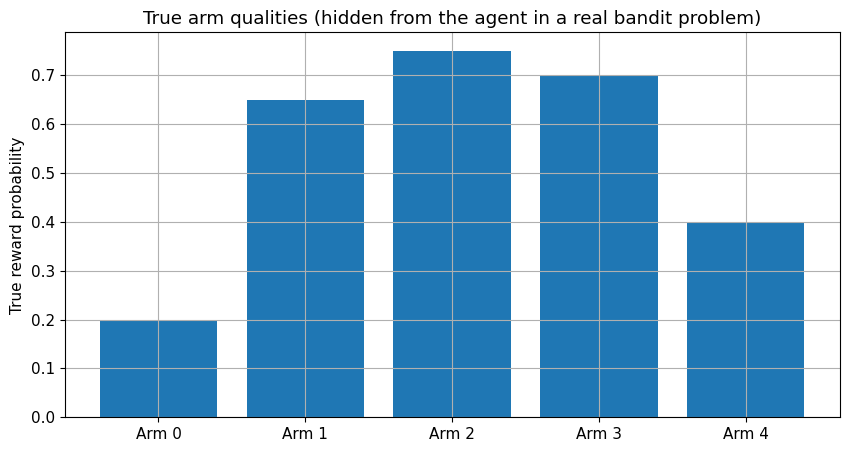

In [12]:
fig, ax = plt.subplots()
arms = np.arange(len(probs))
ax.bar(arms, probs)
ax.set_xticks(arms)
ax.set_xticklabels([f"Arm {i}" for i in arms])
ax.set_ylabel("True reward probability")
ax.set_title("True arm qualities (hidden from the agent in a real bandit problem)")
plt.show()

## A single-run comparison

A single run is good for live teaching because students can literally see success and failure.

### What to watch for

- **Pure greedy** may get stuck with an early lucky arm.
- **$\varepsilon$-greedy** keeps probing alternatives.
- **Optimistic initialization** often explores heavily at the beginning and then settles.

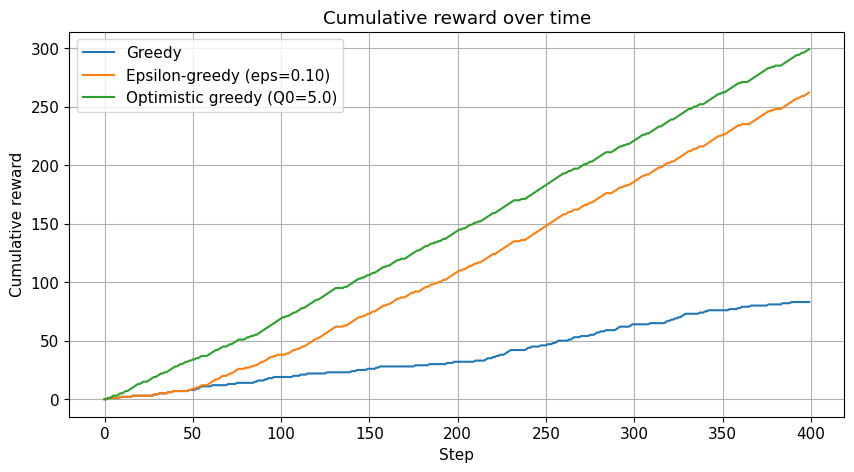

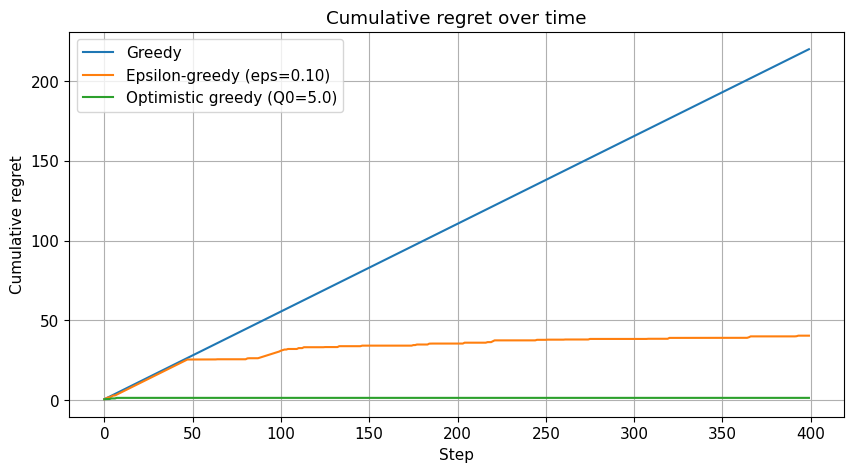

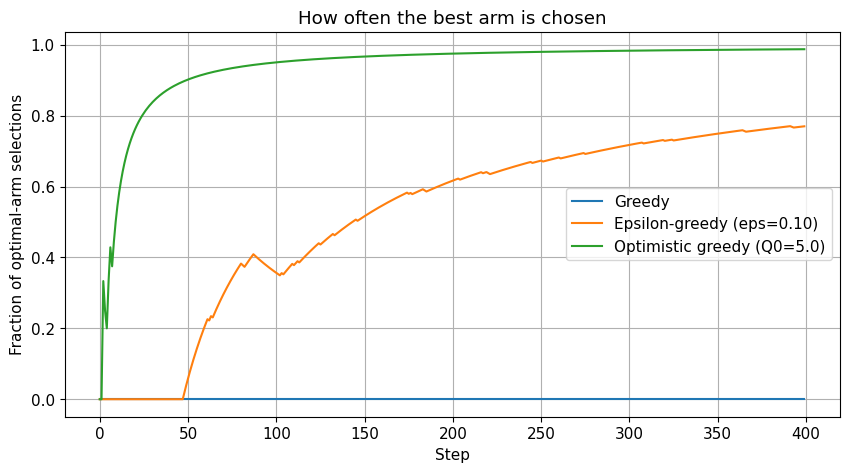

In [13]:
def plot_comparison(results_dict, metric_key, ylabel, title):
    fig, ax = plt.subplots()
    for label, result in results_dict.items():
        ax.plot(result[metric_key], label=label)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()

results_dict = {
    "Greedy": greedy_result,
    "Epsilon-greedy (eps=0.10)": eps_result,
    "Optimistic greedy (Q0=5.0)": optimistic_result,
}

plot_comparison(results_dict, "cum_reward", "Cumulative reward", "Cumulative reward over time")
plot_comparison(results_dict, "cum_regret", "Cumulative regret", "Cumulative regret over time")
plot_comparison(results_dict, "optimal_rate", "Fraction of optimal-arm selections", "How often the best arm is chosen")

## Estimated values after one run

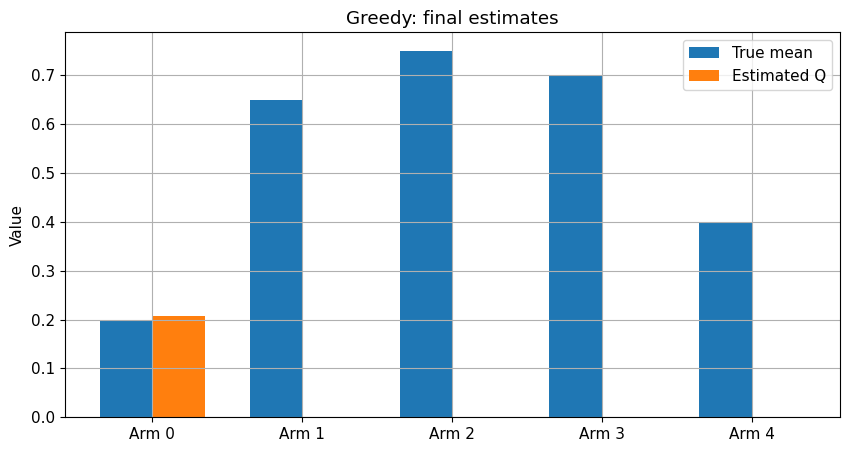

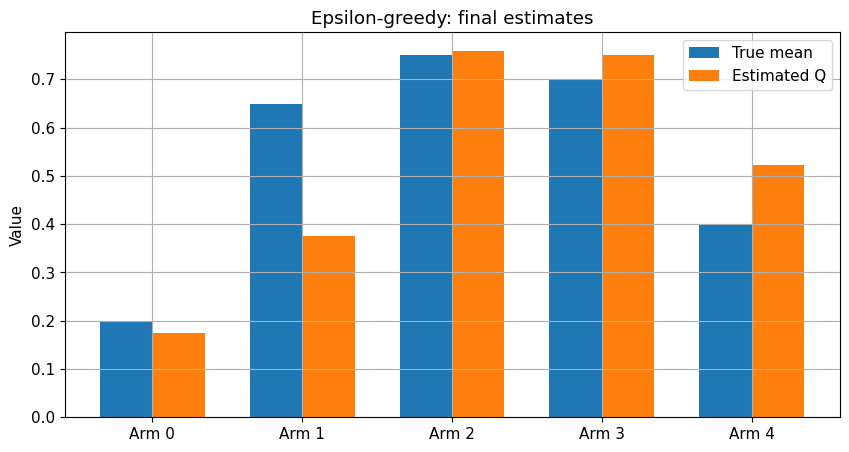

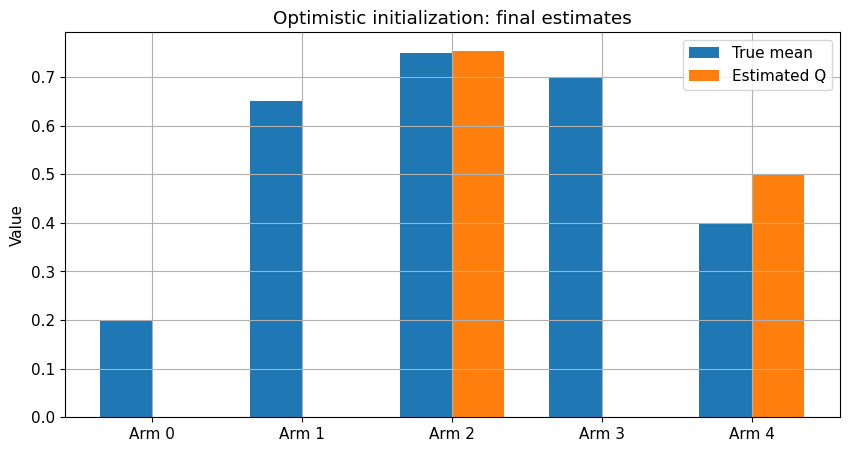

In [14]:
def show_final_estimates(result, title):
    k = len(result["probs"])
    x = np.arange(k)
    width = 0.35

    fig, ax = plt.subplots()
    ax.bar(x - width/2, result["probs"], width=width, label="True mean")
    ax.bar(x + width/2, result["final_q"], width=width, label="Estimated Q")
    ax.set_xticks(x)
    ax.set_xticklabels([f"Arm {i}" for i in x])
    ax.set_ylabel("Value")
    ax.set_title(title)
    ax.legend()
    plt.show()

show_final_estimates(greedy_result, "Greedy: final estimates")
show_final_estimates(eps_result, "Epsilon-greedy: final estimates")
show_final_estimates(optimistic_result, "Optimistic initialization: final estimates")

## How many times was each arm tried?

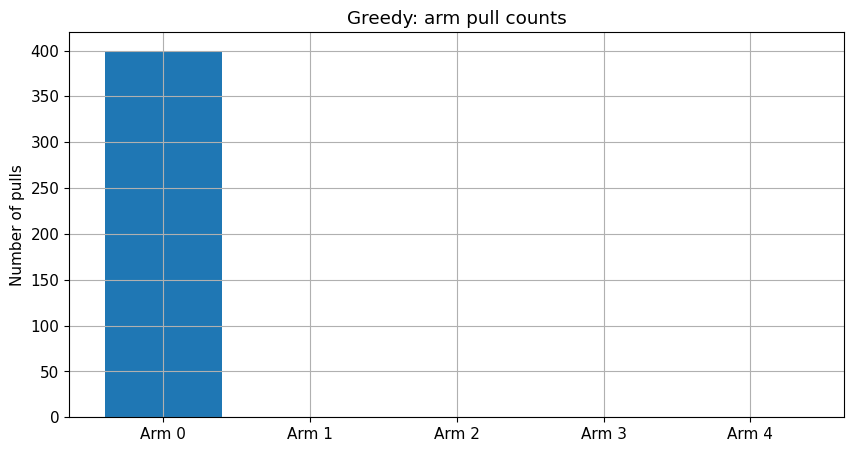

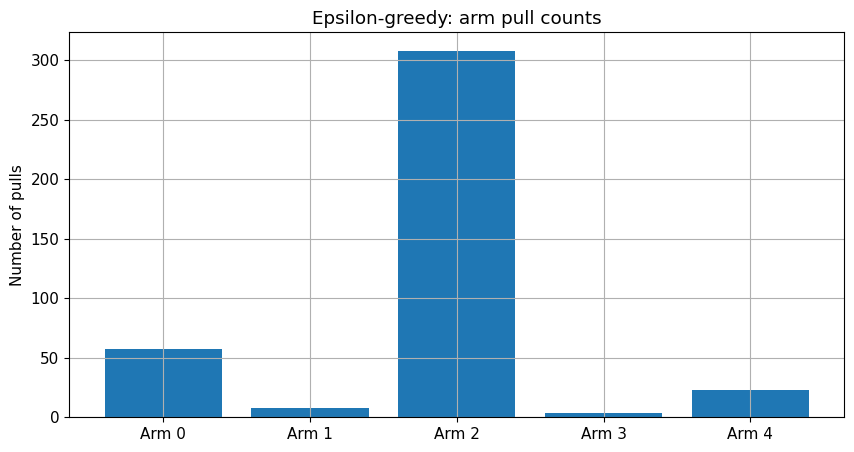

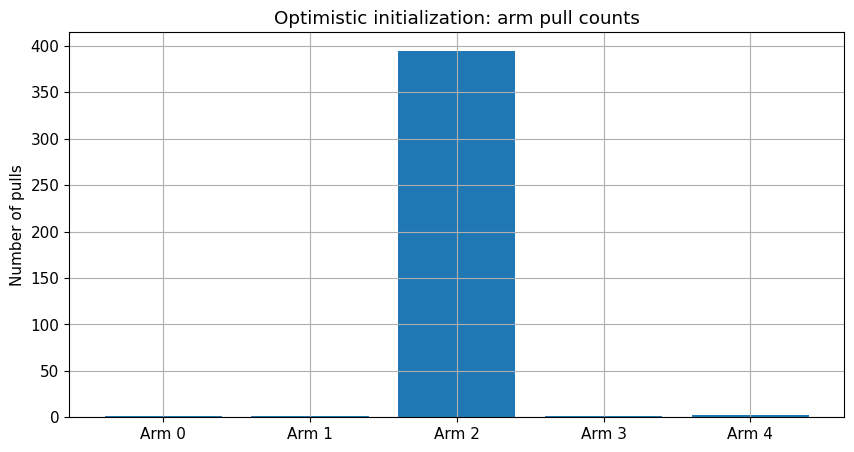

In [15]:
def show_counts(result, title):
    x = np.arange(len(result["probs"]))
    fig, ax = plt.subplots()
    ax.bar(x, result["final_counts"])
    ax.set_xticks(x)
    ax.set_xticklabels([f"Arm {i}" for i in x])
    ax.set_ylabel("Number of pulls")
    ax.set_title(title)
    plt.show()

show_counts(greedy_result, "Greedy: arm pull counts")
show_counts(eps_result, "Epsilon-greedy: arm pull counts")
show_counts(optimistic_result, "Optimistic initialization: arm pull counts")

## Interpreting what happened

### Greedy failure
Pure greedy can fail for a simple reason:
- the first few rewards are noisy,
- an arm can look best **by luck**,
- once greed locks onto it, no further evidence is collected about alternatives.

This is the cleanest possible demonstration that **exploitation alone is not enough**.

### $\varepsilon$-greedy
$\varepsilon$-greedy fixes the problem crudely but effectively:
- most of the time it exploits,
- some of the time it explores at random.

It wastes some pulls on bad arms, but it greatly reduces the risk of getting stuck forever.

### Optimistic initialization
Optimistic initialization says:
- “assume every arm is excellent until evidence proves otherwise.”

That causes a greedy policy to explore early without explicit randomness.

## Regret

A standard evaluation metric for bandits is **regret**.

At time step $t$, if the learner chooses arm $a_t$ and the best possible arm has mean reward $\mu^\*$, then the expected instantaneous regret is:

\[
\mu^\* - \mu(a_t)
\]

The **cumulative regret** after $T$ steps is:

\[
\sum_{t=1}^{T} \bigl(\mu^\* - \mu(a_t)\bigr)
\]

Interpretation:

- low regret means the learner spent most of its time on strong arms,
- high regret means it wasted many selections on poor arms.

A perfect omniscient agent would have regret 0, but of course such an agent would already know the reward distributions.

## Many-run average behavior

Single runs are pedagogically vivid, but they are noisy.

To compare methods more seriously, we average over many independent runs.

In [16]:
def evaluate_strategy(probs, runs=300, steps=400, epsilon=0.1, initial_value=0.0, seed=123):
    cum_rewards = np.zeros((runs, steps))
    cum_regrets = np.zeros((runs, steps))
    optimal_rates = np.zeros((runs, steps))

    for i in range(runs):
        result = run_bandit(
            probs=probs,
            steps=steps,
            epsilon=epsilon,
            initial_value=initial_value,
            seed=seed + 100*i
        )
        cum_rewards[i] = result["cum_reward"]
        cum_regrets[i] = result["cum_regret"]
        optimal_rates[i] = result["optimal_rate"]

    return {
        "avg_cum_reward": cum_rewards.mean(axis=0),
        "avg_cum_regret": cum_regrets.mean(axis=0),
        "avg_optimal_rate": optimal_rates.mean(axis=0),
    }

avg_greedy = evaluate_strategy(probs, runs=400, steps=steps, epsilon=0.0, initial_value=0.0, seed=10)
avg_eps = evaluate_strategy(probs, runs=400, steps=steps, epsilon=0.10, initial_value=0.0, seed=10)
avg_optimistic = evaluate_strategy(probs, runs=400, steps=steps, epsilon=0.0, initial_value=5.0, seed=10)

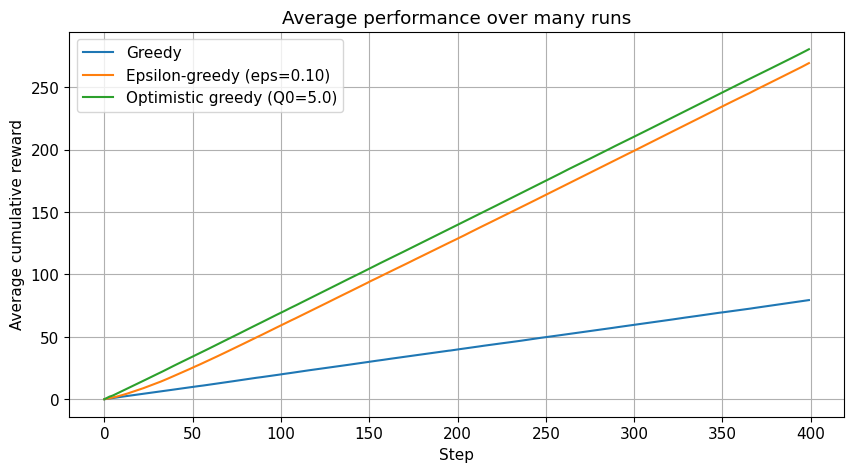

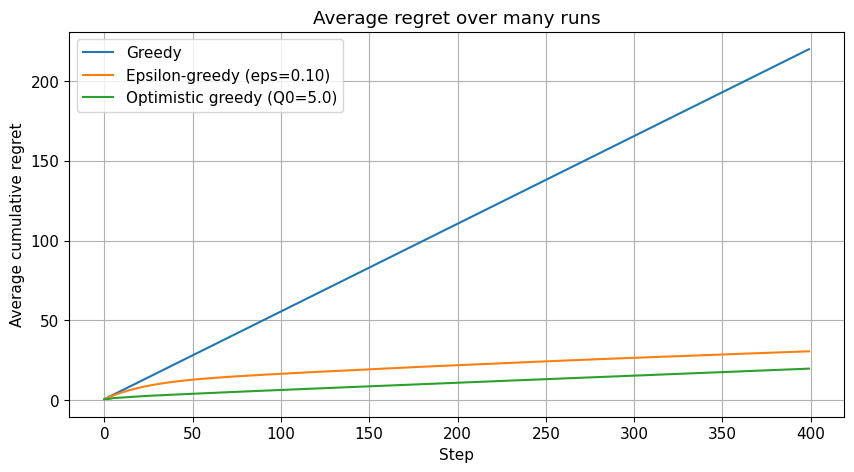

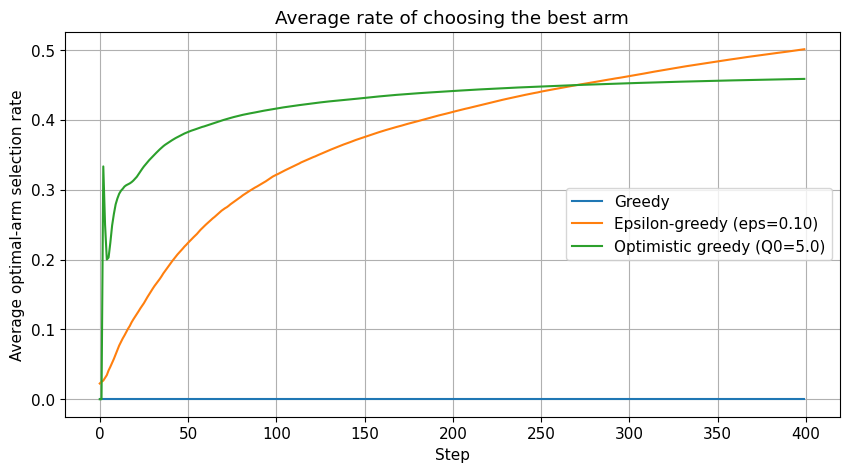

In [17]:
avg_results = {
    "Greedy": avg_greedy,
    "Epsilon-greedy (eps=0.10)": avg_eps,
    "Optimistic greedy (Q0=5.0)": avg_optimistic,
}

def plot_average(avg_results, key, ylabel, title):
    fig, ax = plt.subplots()
    for label, result in avg_results.items():
        ax.plot(result[key], label=label)
    ax.set_xlabel("Step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    plt.show()

plot_average(avg_results, "avg_cum_reward", "Average cumulative reward", "Average performance over many runs")
plot_average(avg_results, "avg_cum_regret", "Average cumulative regret", "Average regret over many runs")
plot_average(avg_results, "avg_optimal_rate", "Average optimal-arm selection rate", "Average rate of choosing the best arm")

## Manual classroom demo

A useful in-class exercise is to let students act as the bandit learner manually.

### Suggested live activity

1. Put 3 arms on the board, for example:
   - Arm A
   - Arm B
   - Arm C
2. Secretly assign reward probabilities, for example:
   - A = 0.3
   - B = 0.6
   - C = 0.4
3. Ask students which arm to pull.
4. Simulate the reward publicly.
5. Keep a running table:

| Step | Chosen Arm | Reward | Estimated Best? |
|---|---:|---:|---:|
| 1 | A | 1 | A |
| 2 | A | 0 | A |
| 3 | B | 1 | B |

6. After 10–15 pulls, ask:
   - Were we too greedy?
   - Did we explore enough?
   - What evidence do we have that one arm is actually best?

This activity usually makes the exploration dilemma immediately concrete.

## GLIE intuition

A policy is often called **GLIE** if it is:

- **greedy in the limit**,
- with **infinite exploration**.

The intuition is:

- early on, the learner should continue exploring,
- but over time, it should behave more and more greedily,
- while still ensuring that actions are not ignored forever too early.

A fixed $\varepsilon$-greedy policy with constant $\varepsilon$ does **not** become fully greedy in the limit.
A purely greedy policy does **not** guarantee sufficient exploration.
A decaying exploration schedule is one way to move toward GLIE-style behavior.

The underlying exploration issue is central in reinforcement learning more broadly, where an agent must trade short-term reward against learning useful information for future decisions.

## Optional extension: decaying epsilon

A natural next step is to replace constant $\varepsilon$ with a decreasing schedule such as:

\[
\varepsilon_t = \frac{1}{t}
\quad \text{or} \quad
\varepsilon_t = \frac{c}{c+t}
\]

This means:

- lots of exploration at the beginning,
- much less exploration later,
- increasingly greedy behavior as estimates improve.

That gives a first concrete bridge from bandits to more formal exploration strategies in reinforcement learning.

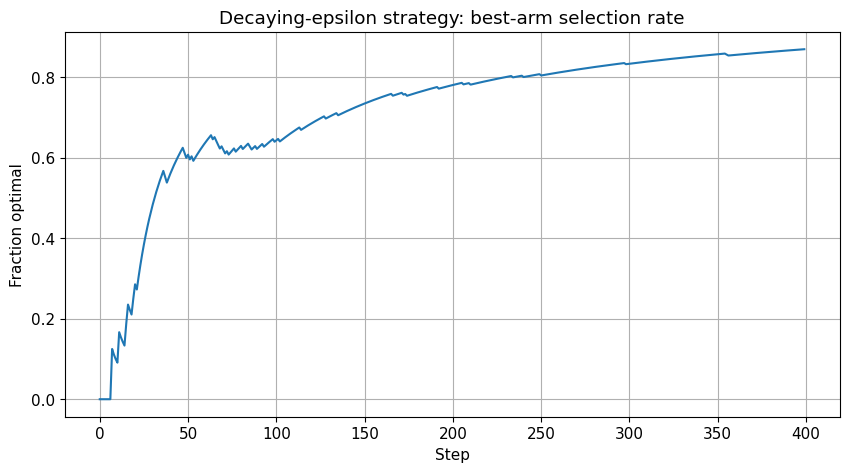

In [18]:
class DecayingEpsilonGreedyAgent:
    def __init__(self, k, c=20.0, initial_value=0.0, seed=None):
        self.k = k
        self.c = float(c)
        self.initial_value = float(initial_value)
        self.rng = np.random.default_rng(seed)
        self.reset()

    def reset(self):
        self.q = np.full(self.k, self.initial_value, dtype=float)
        self.counts = np.zeros(self.k, dtype=int)
        self.t = 0

    def epsilon(self):
        return self.c / (self.c + self.t + 1)

    def select_action(self):
        eps = self.epsilon()
        if self.rng.random() < eps:
            return int(self.rng.integers(self.k))
        return int(np.argmax(self.q))

    def update(self, action, reward):
        self.t += 1
        self.counts[action] += 1
        n = self.counts[action]
        self.q[action] += (reward - self.q[action]) / n


def run_decaying_bandit(probs, steps=500, c=20.0, initial_value=0.0, seed=0):
    env = BernoulliBandit(probs, seed=seed)
    agent = DecayingEpsilonGreedyAgent(
        k=len(probs), c=c, initial_value=initial_value, seed=seed + 1
    )

    rewards = np.zeros(steps)
    regrets = np.zeros(steps)
    optimal = np.zeros(steps)

    for t in range(steps):
        a = agent.select_action()
        r = env.pull(a)
        agent.update(a, r)

        rewards[t] = r
        regrets[t] = env.best_mean - probs[a]
        optimal[t] = int(a == env.best_arm)

    return {
        "cum_reward": np.cumsum(rewards),
        "cum_regret": np.cumsum(regrets),
        "optimal_rate": np.cumsum(optimal) / np.arange(1, steps + 1),
    }

decaying = run_decaying_bandit(probs, steps=steps, c=20.0, seed=1)

fig, ax = plt.subplots()
ax.plot(decaying["optimal_rate"])
ax.set_xlabel("Step")
ax.set_ylabel("Fraction optimal")
ax.set_title("Decaying-epsilon strategy: best-arm selection rate")
plt.show()

## Summary

The bandit problem is small, but conceptually fundamental.

### Main takeaways

- Reinforcement learning is not only about maximizing reward; it is also about **learning under uncertainty**.
- A purely greedy learner can fail because early evidence is noisy.
- **$\varepsilon$-greedy** adds explicit random exploration.
- **Optimistic initialization** adds implicit exploration by overestimating unknown actions.
- **Regret** measures the cost of not knowing the best action from the start.
- Bandits provide clean intuition for later reinforcement learning topics such as exploration schedules, Q-values, and GLIE-style reasoning.

In short:

> **Exploration pays a short-term cost to reduce long-term ignorance.**

## Suggested follow-up topics

- nonstationary bandits,
- Upper Confidence Bound (UCB),
- Thompson sampling,
- contextual bandits,
- gridworld reinforcement learning,
- Q-learning vs SARSA in risky environments.

These are natural next steps once students understand why simple greed is not enough.